# Dynamic BN-SCM hypothesis experiments

This notebook tests the three proposed BN-LTE/SCM hypotheses using the implemented `BayesianNetwork-SCM` pipeline. The analysis uses baseline-to-follow-up ADNI tau pairs, a train-only tau-free pseudotime embedding, and selected temporolimbic/inferior-parietal tau-rate targets.

The current implementation is a leakage-controlled Dynamic BN-SCM prototype, not a full posterior MCMC causal graph. Therefore, the notebook treats edge curves as descriptive, ridge-estimated varying effects rather than definitive causal posterior inclusion probabilities.

## Model used in these experiments

For subject-pair `i` and regional tau target `r`, the prediction target is annualized future tau change:

$$
y_{ir} = \frac{\tau_{ir,t_1} - \tau_{ir,t_0}}{\Delta t_i}
$$

The Dynamic BN-SCM uses baseline multimodal covariates `X_i`, a tau-free latent disease coordinate `Z_i`, and pseudotime-varying parent effects:

$$
y_{ir} = a_r(Z_i) + \sum_{l \in pa(r)} b_{rl}(Z_i) X_{il} + \epsilon_{ir}
$$

Follow-up tau is reconstructed as:

$$
\hat{\tau}_{ir,t_1} = \tau_{ir,t_0} + \Delta t_i \hat{y}_{ir}
$$

This architecture lets the notebook ask whether pT217, amyloid, APOE, and baseline regional tau history contribute to future spatial tau dynamics, while keeping tau-PET out of the pseudotime estimator to reduce outcome leakage.

In [1]:
from pathlib import Path
import csv
import json
import math
import sys

from IPython.display import SVG, Markdown, display

cwd = Path.cwd().resolve()
if cwd.name == "BayesianNetwork-SCM":
    ROOT = cwd
else:
    ROOT = cwd / "BayesianNetwork-SCM"

OUT = ROOT / "outputs" / "hypothesis_experiments"
REPORT_PATH = OUT / "hypothesis_experiment_report.json"

# Set to True to refit all scenarios from the notebook. The saved report is used by default.
RUN_FULL_EXPERIMENTS = False

if RUN_FULL_EXPERIMENTS or not REPORT_PATH.exists():
    sys.path.insert(0, str(ROOT))
    from run_hypothesis_experiments import run_hypothesis_experiments
    report = run_hypothesis_experiments(project_root=ROOT.parent, output_dir=OUT)
else:
    report = json.loads(REPORT_PATH.read_text())

def read_csv_table(path):
    with Path(path).open(newline="", encoding="utf-8") as handle:
        return list(csv.DictReader(handle))

def fmt(value, digits=3):
    try:
        value = float(value)
    except (TypeError, ValueError):
        return str(value)
    if not math.isfinite(value):
        return "NA"
    return f"{value:.{digits}f}"

def markdown_table(rows, columns, max_rows=None):
    rows = rows if max_rows is None else rows[:max_rows]
    header = "| " + " | ".join(columns) + " |"
    sep = "| " + " | ".join(["---"] * len(columns)) + " |"
    body = []
    for row in rows:
        body.append("| " + " | ".join(str(row.get(col, "")) for col in columns) + " |")
    return "\n".join([header, sep] + body)

def show_svg(key):
    display(SVG(filename=report["figures"][key]))

print(f"Loaded report: {REPORT_PATH}")

Loaded report: /Users/nguyenlinhda/Downloads/SPREAD-TOOLBOX/BayesianNetwork-SCM/outputs/hypothesis_experiments/hypothesis_experiment_report.json


**Dataset:** 796 longitudinal pairs from 541 subjects; 10 selected regional tau targets; 30 baseline features.

**Base Dynamic BN-SCM test performance:** median rate MAE = 0.0144, median delta Spearman = 0.222.

| hypothesis | status | evidence |
| --- | --- | --- |
| H1 pT217 -> tau decoupling | weak / not confirmed | strict pattern fraction=0.00; late<early=0.50 |
| H2 transcriptomic resilience gating | not testable | no AHBA/regional gene-expression matrix found in project outputs |
| H3 PART vs AD shared route | not confirmed | test route rho=-0.08; kinetic ratio=5.32 |

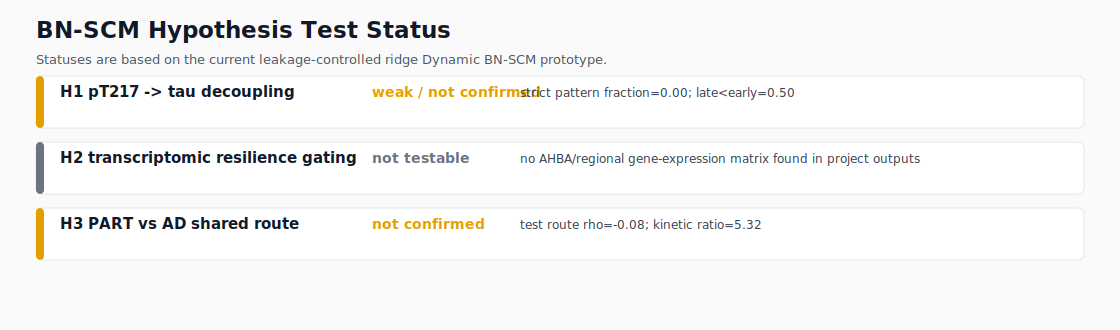

In [2]:
data = report["data"]
base = report["base_model"]
status_rows = report["hypothesis_status"]

display(Markdown(
    f"**Dataset:** {data['pairs']} longitudinal pairs from {data['subjects']} subjects; "
    f"{data['target_count']} selected regional tau targets; {data['feature_count']} baseline features.\n\n"
    f"**Base Dynamic BN-SCM test performance:** median rate MAE = {fmt(base['test_rate_mae_median'], 4)}, "
    f"median delta Spearman = {fmt(base['test_delta_spearman_median'], 3)}.\n\n"
    + markdown_table(status_rows, ["hypothesis", "status", "evidence"])
))
show_svg("hypothesis_status")

## H1: pT217-to-tau decoupling

Hypothesis: plasma pT217 has a strong direct effect on future tau-PET early in pseudotime, then decouples late as regional tau dynamics become more autonomous.

Operational test in this prototype: for each target region, estimate the varying effect of baseline `plasma_pt217` across pseudotime bins and check whether the late-bin absolute effect is near zero and lower than the early-bin effect. This is a descriptive varying-effect test, not a posterior edge-inclusion test.

**Result:** strict H1 pattern fraction = 0.00; late < early fraction = 0.50; late near-zero fraction = 0.80.

Interpretation: the current data/model do **not** confirm a strong pT217 decoupling transition. pT217 is selected often, but the early-vs-late pattern is inconsistent across regions.

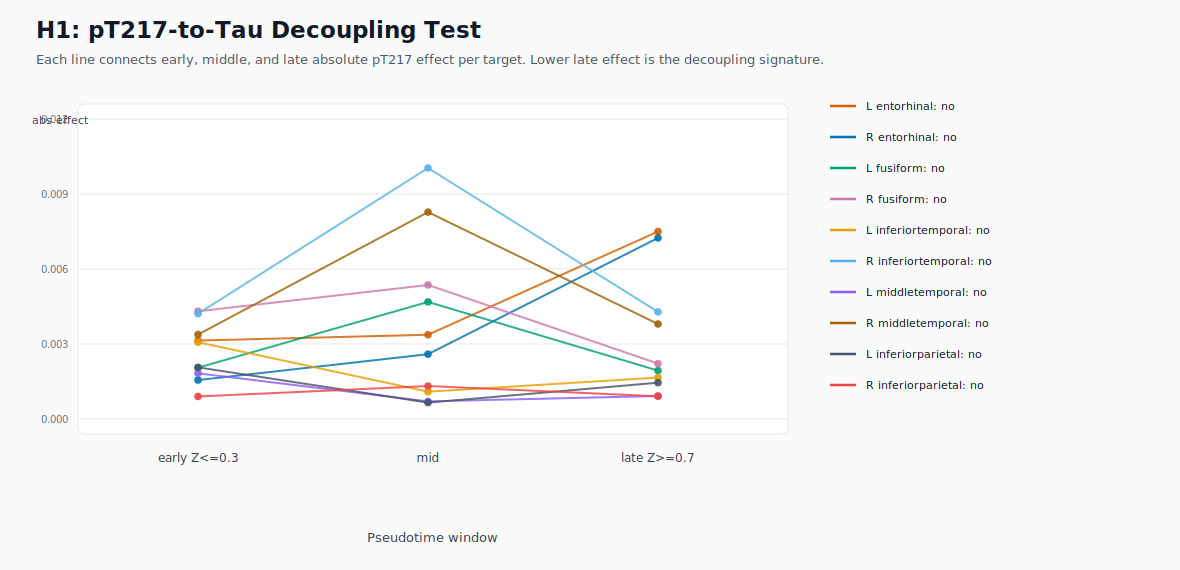

| target_region | pt217_selected | pt217_early_abs | pt217_late_abs | late_less_than_early | strict_h1_pattern |
| --- | --- | --- | --- | --- | --- |
|  |  |  |  |  | False |
|  |  |  |  |  | False |
|  |  |  |  |  | False |
|  |  |  |  |  | False |
|  |  |  |  |  | False |
|  |  |  |  |  | False |
|  |  |  |  |  | False |
|  |  |  |  |  | False |
|  |  |  |  |  | False |
|  |  |  |  |  | False |

In [3]:
h1 = report["hypotheses"]["H1_pT217_tau_decoupling"]
h1_rows = read_csv_table(report["tables"]["h1"])

display(Markdown(
    f"**Result:** strict H1 pattern fraction = {fmt(h1['strict_h1_pattern_fraction'], 2)}; "
    f"late < early fraction = {fmt(h1['late_less_than_early_fraction'], 2)}; "
    f"late near-zero fraction = {fmt(h1['late_near_zero_fraction'], 2)}.\n\n"
    "Interpretation: the current data/model do **not** confirm a strong pT217 decoupling transition. "
    "pT217 is selected often, but the early-vs-late pattern is inconsistent across regions."
))
show_svg("h1_pt217_decoupling")
display(Markdown(markdown_table(h1_rows, [
    "target_region", "pt217_selected", "pt217_early_abs", "pt217_late_abs", "late_less_than_early", "strict_h1_pattern"
])))

## H2: transcriptomic resilience gating

Hypothesis: regional resilience gene expression gates the amyloid-to-tau cascade.

This cannot be fully tested in the current workspace because no AHBA or other region-aligned transcriptomic matrix was found. The notebook therefore checks only the precondition: whether amyloid features are useful parents for future tau-rate prediction. A real H2 test requires regional expression scores, such as SR/SV module scores or named-gene scores aligned to the same atlas labels.

**H2 status:** not_testable_current_data. Candidate gene files found: 0.

Amyloid parent precondition: selected fraction = 1.00, mean max absolute amyloid effect = 0.0032.

The ablation result is still useful: removing amyloid PET features worsens held-out rate MAE more than removing pT217 or plasma Abeta ratio in this run.

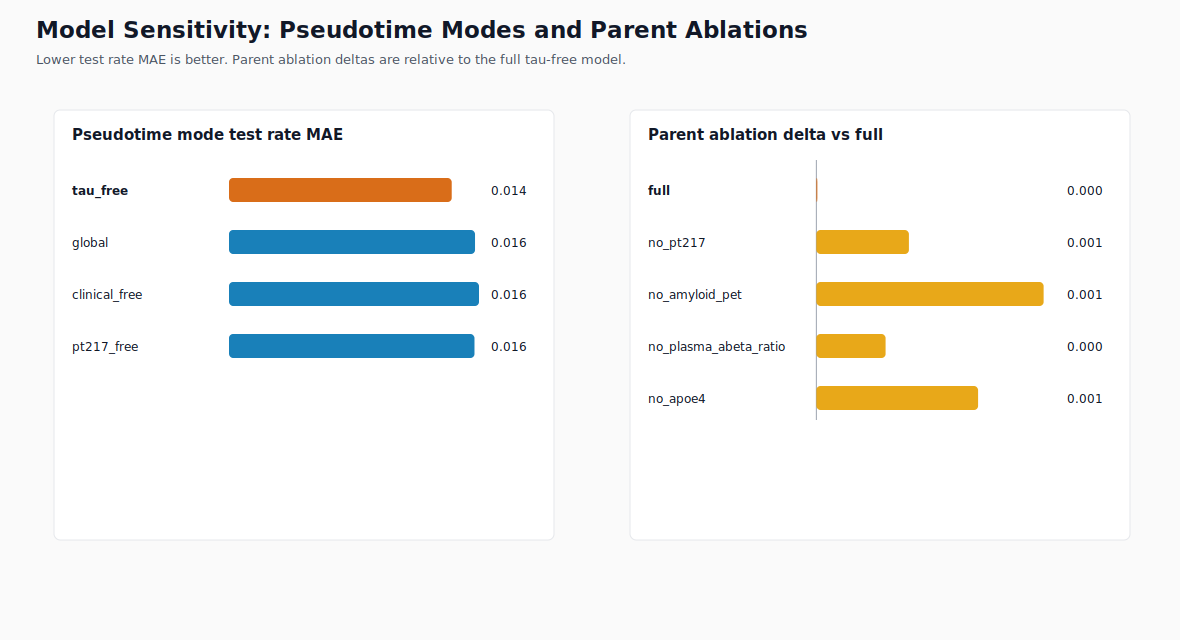

| scenario | excluded_features | test_rate_mae_median | test_delta_spearman_median | test_rate_mae_delta_vs_full |
| --- | --- | --- | --- | --- |
| full |  | 0.014397516692900465 | 0.22154420998362373 | 0.0 |
| no_pt217 | plasma_pt217 | 0.014961146027559304 | 0.18181818181818182 | 0.0005636293346588384 |
| no_amyloid_pet | amyloid_summary_suvr;amyloid_centiloids;amyloid_positive | 0.015781619502543073 | 0.16363636363636364 | 0.001384102809642608 |
| no_plasma_abeta_ratio | plasma_ab42_ab40 | 0.01481911449077776 | 0.17575757575757575 | 0.00042159779787729473 |
| no_apoe4 | apoe4_dose | 0.015382455824095304 | 0.2121212121212121 | 0.0009849391311948386 |

In [4]:
h2 = report["hypotheses"]["H2_transcriptomic_resilience_gating"]
ablation_rows = read_csv_table(report["tables"]["parent_ablation"])

display(Markdown(
    f"**H2 status:** {h2['status']}. Candidate gene files found: {len(h2['candidate_gene_files'])}.\n\n"
    f"Amyloid parent precondition: selected fraction = {fmt(h2['precondition_amyloid_parent_selected_fraction'], 2)}, "
    f"mean max absolute amyloid effect = {fmt(h2['precondition_mean_amyloid_max_abs_effect'], 4)}.\n\n"
    "The ablation result is still useful: removing amyloid PET features worsens held-out rate MAE more than removing pT217 or plasma Abeta ratio in this run."
))
show_svg("ablation_summary")
display(Markdown(markdown_table(ablation_rows, [
    "scenario", "excluded_features", "test_rate_mae_median", "test_delta_spearman_median", "test_rate_mae_delta_vs_full"
])))

## H3: PART-like vs AD-continuum route

Hypothesis: amyloid-negative tau-positive participants and amyloid-positive tau-positive participants share the same spatial tau route, with AD reflecting kinetic acceleration.

Operational test: define A status from the baseline amyloid-positive feature and define T+ using a train-derived CN 75th percentile threshold on meta-temporal tau. Compare the spatial vector of regional tau rates between A-T+ and A+T+ groups on the held-out test split.

**Group counts:** {'A+T+': 211, 'A+T-': 132, 'A-T+': 97, 'A-T-': 352, 'unclassified': 4}

**Held-out test:** A-T+ n = 19, A+T+ n = 48; observed spatial route Spearman = -0.079, predicted route Spearman = 0.248; observed kinetic ratio AD/PART = 5.32.

Interpretation: kinetic acceleration is supported, but the shared-route claim is not confirmed in the current selected-region held-out test.

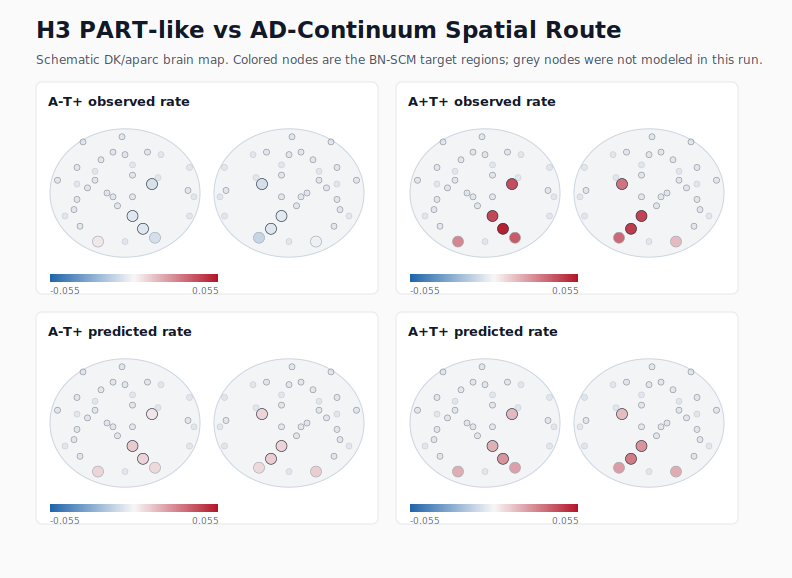

| split | part_like_n | ad_continuum_n | observed_route_spearman | predicted_route_spearman | observed_kinetic_ratio_ad_over_part |
| --- | --- | --- | --- | --- | --- |
| train | 63 | 111 | 0.04242424242424241 | 0.01818181818181818 | 16.44073532285813 |
| validation | 15 | 52 | 0.07878787878787878 | -0.09090909090909088 | 4.370120600467664 |
| test | 19 | 48 | -0.07878787878787878 | 0.24848484848484845 | 5.315709175541502 |
| all | 97 | 211 | -0.01818181818181818 | -0.17575757575757575 | 23.891902544233783 |

In [5]:
h3 = report["hypotheses"]["H3_PART_AD_continuum"]
h3_test = h3["test_result"]
h3_rows = read_csv_table(report["tables"]["h3"])

display(Markdown(
    f"**Group counts:** {h3['group_counts_all']}\n\n"
    f"**Held-out test:** A-T+ n = {h3_test['part_like_n']}, A+T+ n = {h3_test['ad_continuum_n']}; "
    f"observed spatial route Spearman = {fmt(h3_test['observed_route_spearman'], 3)}, "
    f"predicted route Spearman = {fmt(h3_test['predicted_route_spearman'], 3)}; "
    f"observed kinetic ratio AD/PART = {fmt(h3_test['observed_kinetic_ratio_ad_over_part'], 2)}.\n\n"
    "Interpretation: kinetic acceleration is supported, but the shared-route claim is not confirmed in the current selected-region held-out test."
))
show_svg("h3_part_ad_route")
display(Markdown(markdown_table(h3_rows, [
    "split", "part_like_n", "ad_continuum_n", "observed_route_spearman", "predicted_route_spearman", "observed_kinetic_ratio_ad_over_part"
])))

## Brain-map forecast diagnostics

The panels below compare initial baseline tau, empirical follow-up tau, BN-SCM predicted follow-up tau, empirical change, predicted change, and prediction error. Grey regions are DK/aparc regions not included as BN-SCM targets in this prototype.

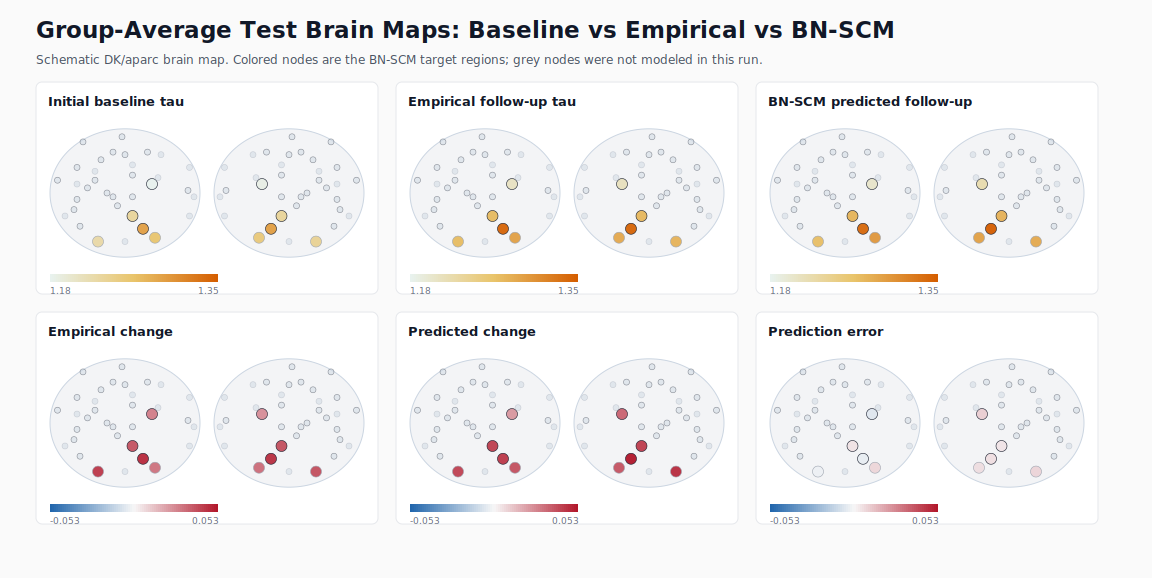

In [6]:
show_svg("brain_group_forecast")

## Representative subject cases

These panels provide qualitative error analysis across a stable CN case, a progressing MCI case, and an AD case with high baseline tau burden. They are intended for model inspection, not for subject-level clinical interpretation.

| label | RID | diagnosis | z | baseline_mean_tau | observed_mean_delta | observed_abs_delta |
| --- | --- | --- | --- | --- | --- | --- |
| CN stable | 4119 | CN | 0.1370272181197719 | 1.2429999999999999 | -0.005400000000000005 | 0.010600000000000009 |
| MCI progressing | 1378 | MCI | 0.40111303706093454 | 2.0721 | 0.3964000000000001 | 0.3964000000000001 |
| AD high baseline | 6216 | AD | 0.9436180953127101 | 2.0549000000000004 | -0.14470000000000002 | 0.19229999999999997 |

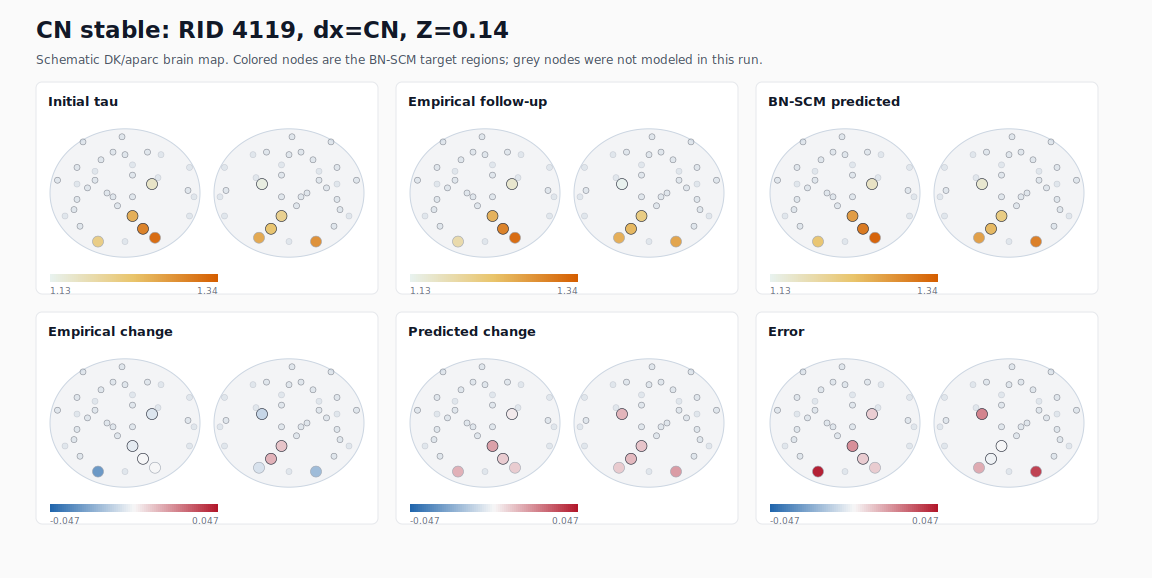

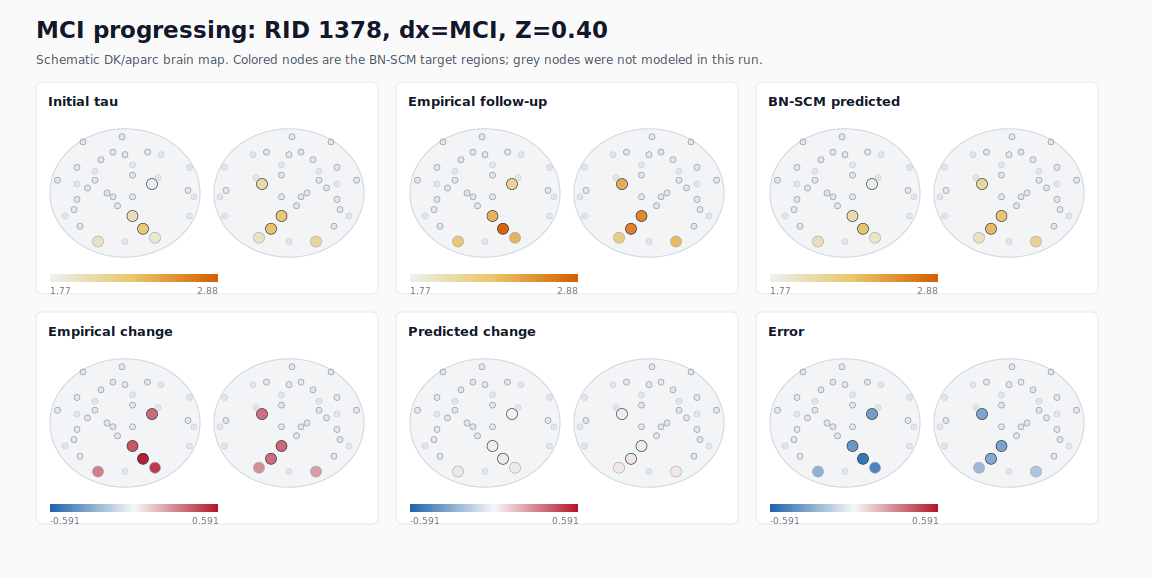

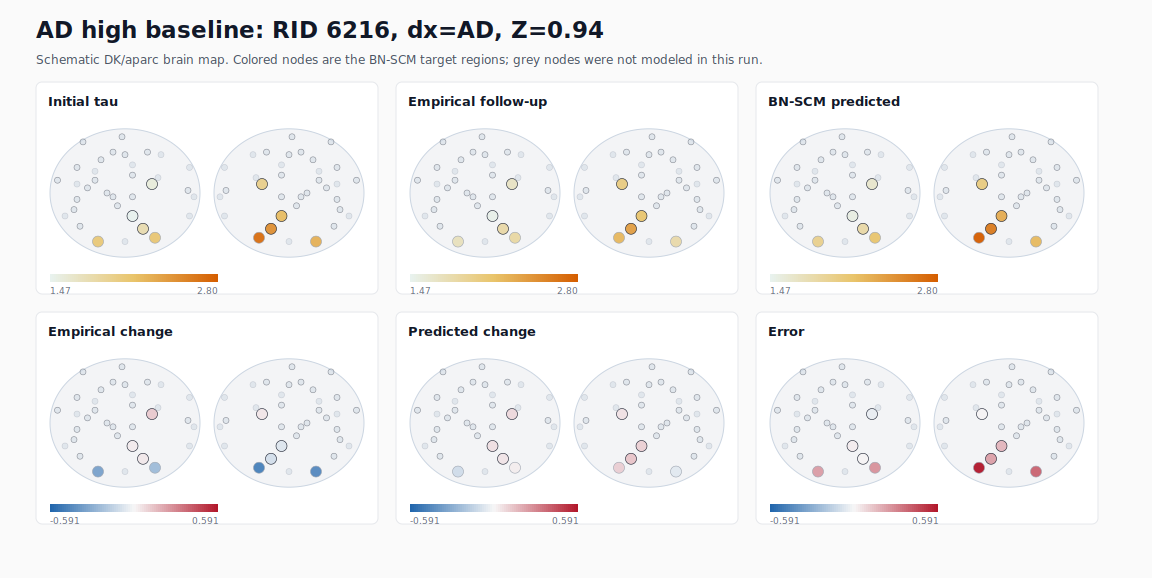

In [7]:
subject_rows = read_csv_table(report["tables"]["subjects"])
display(Markdown(markdown_table(subject_rows, [
    "label", "RID", "diagnosis", "z", "baseline_mean_tau", "observed_mean_delta", "observed_abs_delta"
])))
for key in ["brain_subject_cn_stable", "brain_subject_mci_progressing", "brain_subject_ad_high_baseline"]:
    show_svg(key)

## Pseudotime and reliability checks

The hypothesis conclusions should only be trusted if they are not artifacts of a single pseudotime construction or one small disease stage. The first diagnostic compares alternative pseudotime definitions. The second diagnostic shows held-out error by pseudotime bin.

**Pseudotime sensitivity**

| scenario | test_rate_mae_median | test_delta_spearman_median | selected_pseudotime_features |
| --- | --- | --- | --- |
| tau_free | 0.014397516692900465 | 0.22154420998362373 | 18 |
| global | 0.015903722419725083 | 0.20061162649765218 | 30 |
| clinical_free | 0.016161182677991603 | 0.2121212121212121 | 26 |
| pt217_free | 0.015869169161042192 | 0.1911858315520097 | 29 |

**Pseudotime-bin errors**

| split | z_bin | n_pairs | rate_mae | delta_spearman_median |
| --- | --- | --- | --- | --- |
| train | early | 332 | 0.017448014617840187 | 0.1515151515151515 |
| train | middle | 100 | 0.04180897880338222 | 0.2848484848484848 |
| train | late | 41 | 0.06506062051288179 | 0.41818181818181815 |
| validation | early | 102 | 0.02200893025983889 | 0.12442691800437009 |
| validation | middle | 52 | 0.04801997006462714 | 0.3333333333333333 |
| validation | late | 13 | 0.12007033573046694 | 0.3939393939393939 |
| test | early | 102 | 0.0188215859133081 | 0.12442691800437009 |
| test | middle | 42 | 0.04302983651096546 | 0.280396619099916 |
| test | late | 12 | 0.06352817357086243 | 0.3878787878787878 |

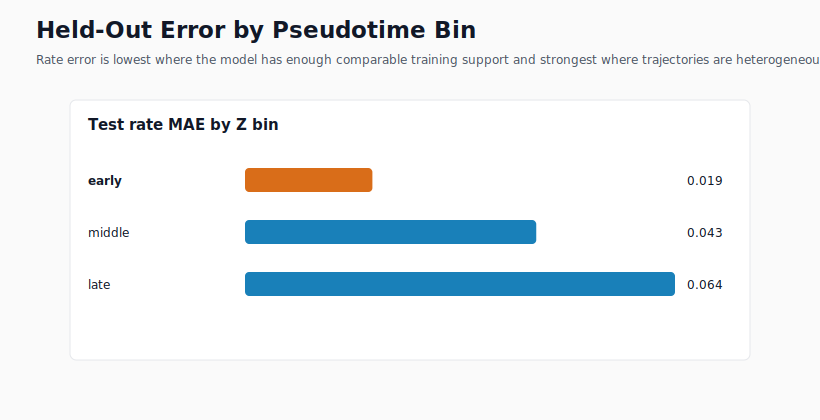

In [8]:
pt_rows = read_csv_table(report["tables"]["pseudotime_sensitivity"])
z_rows = read_csv_table(report["tables"]["z_bins"])

display(Markdown("**Pseudotime sensitivity**\n\n" + markdown_table(pt_rows, [
    "scenario", "test_rate_mae_median", "test_delta_spearman_median", "selected_pseudotime_features"
])))
display(Markdown("**Pseudotime-bin errors**\n\n" + markdown_table(z_rows, [
    "split", "z_bin", "n_pairs", "rate_mae", "delta_spearman_median"
])))
show_svg("z_bin_errors")

## Recommended next experiments

The most informative next steps are not simply more plots. They are experiments that would change whether the hypotheses can be accepted or rejected.

In [9]:
display(Markdown(markdown_table(report["recommended_experiments"], ["priority", "experiment", "reason"])))

| priority | experiment | reason |
| --- | --- | --- |
| 1 | Full posterior edge sampling for the current leakage-controlled design | The present edge curves are ridge estimates; H1 and causal PIP claims require posterior uncertainty. |
| 2 | AHBA DK/aparc expression join for H2 | Transcriptomic gating cannot be evaluated until regional SR/SV gene-module scores are available. |
| 3 | A/T threshold sensitivity for PART-like H3 | The current T+ cutoff is train-derived; robustness over accepted tau-positivity thresholds is needed. |
| 4 | Longitudinal calibration curves by pseudotime bin | Shows whether BN-SCM only helps early disease or also handles late autonomous tau dynamics. |
| 5 | Target expansion to all 68 regional tau rates | The brain-map diagnostics are selected-region only; whole-cortex forecasting is needed for spatial route claims. |